# Assignment 3: Kaggle Regression with Abalone Dataset

**Todd DeLozier**

This notebook covers the Kaggle portion of Assignment 3:

- One model using **regularization** (to inform a compact subset-style model)
- One model using **principal components regression (PCR)**
- Diagnostics to support core regression assumptions
- Creation of Kaggle-ready **submission CSVs**

The notebook expects `train.csv` and `test.csv` to be located in the **same folder** as this notebook.


In [1]:
from __future__ import annotations

import os
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.decomposition import PCA

import statsmodels.api as sm

np.random.seed(1)

print("Setup complete.")


Setup complete.


In [2]:
# Locate train/test CSVs (assumes they are in the same folder as the notebook, i.e., current working directory)
cwd = Path.cwd()

train_path = cwd / "train.csv"
test_path  = cwd / "test.csv"

if not train_path.exists() or not test_path.exists():
    # Fall back to searching the current tree (helps when running from a different working directory)
    candidates_train = list(cwd.rglob("train.csv"))
    candidates_test  = list(cwd.rglob("test.csv"))
    train_path = candidates_train[0] if candidates_train else train_path
    test_path  = candidates_test[0] if candidates_test else test_path

print("Working directory:", cwd)
print("train.csv:", train_path, "exists:", train_path.exists())
print("test.csv :", test_path,  "exists:", test_path.exists())


Working directory: c:\Users\toddd\Documents\Azure_DevOps\Career Development-1\Todd_DeLozier\School\National_University_PhD_Data_Science\Predictive_Analytics\Week_3
train.csv: c:\Users\toddd\Documents\Azure_DevOps\Career Development-1\Todd_DeLozier\School\National_University_PhD_Data_Science\Predictive_Analytics\Week_3\train.csv exists: True
test.csv : c:\Users\toddd\Documents\Azure_DevOps\Career Development-1\Todd_DeLozier\School\National_University_PhD_Data_Science\Predictive_Analytics\Week_3\test.csv exists: True


In [3]:
train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

print("Train shape:", train.shape)
print("Test  shape:", test.shape)
train.head()


Train shape: (90615, 10)
Test  shape: (60411, 9)


,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


In [4]:
# Identify target and ID columns
# Typical Abalone regression target is often 'Rings' (proxy for age).
# If 'Rings' is not present, fall back to a reasonable guess: last non-ID column.

possible_id_cols = [c for c in ["id", "ID", "Id"] if c in train.columns or c in test.columns]
ID_COL = possible_id_cols[0] if possible_id_cols else None

TARGET = "Rings" if "Rings" in train.columns else None
if TARGET is None:
    # choose last column that isn't an ID
    candidates = [c for c in train.columns if c != ID_COL]
    TARGET = candidates[-1]

print("ID_COL  :", ID_COL)
print("TARGET  :", TARGET)

# Split X/y
y = train[TARGET].copy()
X = train.drop(columns=[TARGET])


ID_COL  : id
TARGET  : Rings


## Quick EDA

The goal here is lightweight: confirm data types, missingness, and basic distributions.


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,90615.0,NaN,NaN,NaN,45307.0,26158.441658,0.0,22653.5,45307.0,67960.5,90614.0
Sex,90615,3,I,33093,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Length,90615.0,NaN,NaN,NaN,0.517098,0.118217,0.075,0.445,0.545,0.6,0.815
Diameter,90615.0,NaN,NaN,NaN,0.401679,0.098026,0.055,0.345,0.425,0.47,0.65
Height,90615.0,NaN,NaN,NaN,0.135464,0.038008,0.0,0.11,0.14,0.16,1.13
Whole weight,90615.0,NaN,NaN,NaN,0.789035,0.457671,0.002,0.419,0.7995,1.0675,2.8255
Whole weight.1,90615.0,NaN,NaN,NaN,0.340778,0.204428,0.001,0.1775,0.33,0.463,1.488
Whole weight.2,90615.0,NaN,NaN,NaN,0.169422,0.100909,0.0005,0.0865,0.166,0.2325,0.76
Shell weight,90615.0,NaN,NaN,NaN,0.225898,0.130203,0.0015,0.12,0.225,0.305,1.005
Rings,90615.0,NaN,NaN,NaN,9.696794,3.176221,1.0,8.0,9.0,11.0,29.0



Missing values (train):


id                0
Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Whole weight.1    0
Whole weight.2    0
Shell weight      0
Rings             0
dtype: int64

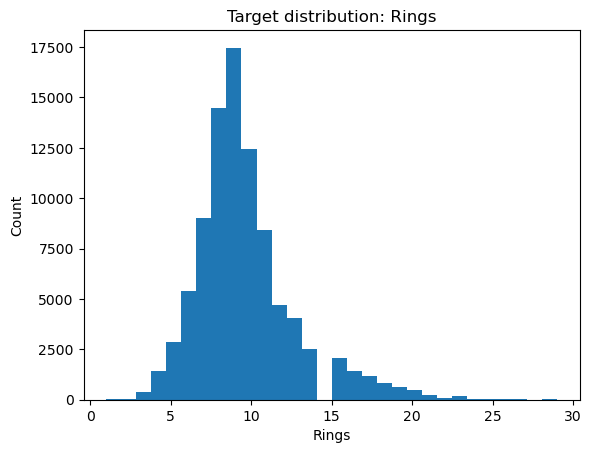

In [5]:
display(train.describe(include="all").T.head(25))
print("\nMissing values (train):")
display(train.isna().sum().sort_values(ascending=False).head(20))

# Target distribution
plt.figure()
plt.hist(y, bins=30)
plt.title(f"Target distribution: {TARGET}")
plt.xlabel(TARGET)
plt.ylabel("Count")
plt.show()


## Preprocessing

- Numeric features: median imputation + scaling
- Categorical features: most-frequent imputation + one-hot encoding

This keeps models comparable and allows regularization/PCR to behave sensibly.


In [6]:
# Identify feature types
cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

print("Categorical columns:", cat_cols)
print("Numeric columns     :", num_cols)

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols),
    ],
    remainder="drop"
)


Categorical columns: ['Sex']
Numeric columns     : ['id', 'Length', 'Diameter', 'Height', 'Whole weight', 'Whole weight.1', 'Whole weight.2', 'Shell weight']


In [7]:
def rmse_cv(model, X, y, n_splits=5, random_state=1):
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    # sklearn uses negative MSE for scoring; convert to RMSE
    scores = cross_val_score(model, X, y, scoring="neg_mean_squared_error", cv=cv)
    rmse = np.sqrt(-scores)
    return rmse.mean(), rmse.std()


## Baseline model (OLS / Linear Regression)

This establishes a simple reference RMSE under cross-validation.


In [8]:
baseline_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("reg", LinearRegression())
])

mean_rmse, std_rmse = rmse_cv(baseline_model, X, y)
print(f"Baseline CV RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}")


Baseline CV RMSE: 1.9956 ± 0.0169


## Model 1: Regularization (Elastic Net)

Elastic Net is useful when predictors are correlated because it blends ridge (L2) and lasso (L1).
I use cross-validation to select the penalty strength and mixing ratio.

This model also gives a coefficient-based importance signal that I use to build a compact subset-style model.


In [9]:
elastic_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("reg", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
        alphas=None,
        cv=5,
        max_iter=20000,
        random_state=1
    ))
])

mean_rmse, std_rmse = rmse_cv(elastic_model, X, y)
print(f"ElasticNetCV RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}")

# Fit on full training data to extract coefficients
elastic_model.fit(X, y)
enet = elastic_model.named_steps["reg"]
print("Chosen alpha:", float(enet.alpha_))
print("Chosen l1_ratio:", float(enet.l1_ratio_))


ElasticNetCV RMSE: 1.9960 ± 0.0169
Chosen alpha: 0.0022067168235885585
Chosen l1_ratio: 1.0


In [10]:
# Extract feature names after preprocessing and pair with coefficients
# This works with scikit-learn >= 1.0 that supports get_feature_names_out.
prep = elastic_model.named_steps["preprocess"]
feature_names = prep.get_feature_names_out()
coefs = pd.Series(enet.coef_, index=feature_names).sort_values(key=np.abs, ascending=False)

display(coefs.head(30))


num__Whole weight.1   -3.155036
num__Shell weight      2.747617
num__Whole weight      1.528506
num__Height            0.797679
cat__Sex_I            -0.695671
num__Whole weight.2   -0.625887
num__Diameter          0.588763
num__Length           -0.036710
num__id               -0.011445
cat__Sex_F             0.007501
cat__Sex_M             0.000000
dtype: float64

## Subset-style model informed by regularization

Best subset selection is combinatorial and not practical with many derived features (especially after one-hot encoding).
Instead, I use Elastic Net to rank features by absolute coefficient magnitude, then refit an OLS-style model using the top *k* features.

This provides a transparent, compact model that behaves like a subset selection outcome.


In [11]:
from sklearn.feature_selection import SelectFromModel

# Choose a simple rule: keep the top k coefficients by absolute value
def top_k_mask(coef_series, k):
    idx = np.argsort(np.abs(coef_series.values))[::-1][:k]
    mask = np.zeros(len(coef_series), dtype=bool)
    mask[idx] = True
    return mask

# Transform data once to get the design matrix
X_design = preprocess.fit_transform(X)

# Try a few k values and choose the best CV RMSE
k_grid = [5, 8, 10, 12, 15, 20, 25, 30]
results = []

# Need feature names after fitting preprocess
feature_names = preprocess.get_feature_names_out()
coef_series = pd.Series(enet.coef_, index=feature_names)

cv = KFold(n_splits=5, shuffle=True, random_state=1)

for k in k_grid:
    mask = top_k_mask(coef_series, k)
    Xk = X_design[:, mask]

    # OLS-style model on selected columns
    model_k = LinearRegression()
    scores = cross_val_score(model_k, Xk, y, scoring="neg_mean_squared_error", cv=cv)
    rmse = np.sqrt(-scores).mean()
    results.append((k, rmse))

subset_df = pd.DataFrame(results, columns=["k_features", "cv_rmse"]).sort_values("cv_rmse")
display(subset_df)

best_k = int(subset_df.iloc[0]["k_features"])
print("Best k by CV RMSE:", best_k)


,k_features,cv_rmse
2,10,1.995569
3,12,1.995569
5,20,1.995569
4,15,1.995569
6,25,1.995569
7,30,1.995569
1,8,1.995580
0,5,2.009333


Best k by CV RMSE: 10


In [12]:
# Fit final subset-style model with best_k and capture which features were selected
mask = top_k_mask(coef_series, best_k)
selected_features = feature_names[mask]

print("Selected features:")
for f in selected_features:
    print(" -", f)

Xk = X_design[:, mask]
subset_lr = LinearRegression()
subset_lr.fit(Xk, y)

# Evaluate CV RMSE for this chosen k
scores = cross_val_score(subset_lr, Xk, y, scoring="neg_mean_squared_error", cv=cv)
subset_rmse = np.sqrt(-scores)
print(f"Subset-style CV RMSE: {subset_rmse.mean():.4f} ± {subset_rmse.std():.4f}")


Selected features:
 - num__id
 - num__Length
 - num__Diameter
 - num__Height
 - num__Whole weight
 - num__Whole weight.1
 - num__Whole weight.2
 - num__Shell weight
 - cat__Sex_F
 - cat__Sex_I
Subset-style CV RMSE: 1.9956 ± 0.0169


## Model 2: Principal Components Regression (PCR)

PCR = PCA on standardized predictors followed by linear regression on the principal components.
I select the number of components using cross-validation.


Candidate PCA components up to: 11


,n_components,cv_rmse
10,11,1.995569
9,10,1.995569
8,9,1.995956
7,8,2.006488
6,7,2.007075
5,6,2.189653
4,5,2.321808
3,4,2.323802
0,1,2.429822
1,2,2.429830


Best n_components: 11


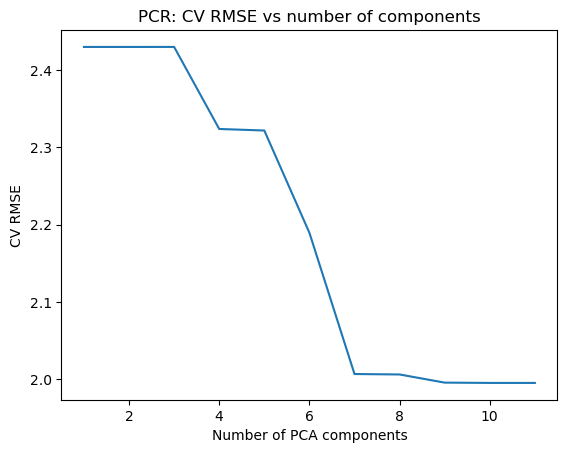

In [13]:
# Build a PCR pipeline: preprocess -> PCA -> linear regression
pca = PCA()
pcr_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("pca", pca),
    ("reg", LinearRegression())
])

# Determine a reasonable upper bound for components from the transformed matrix shape.
Xt = preprocess.fit_transform(X)
max_components = min(40, Xt.shape[1])  # keep runtime manageable
print("Candidate PCA components up to:", max_components)

cv = KFold(n_splits=5, shuffle=True, random_state=1)
comp_grid = list(range(1, max_components + 1))

pcr_results = []
for n_comp in comp_grid:
    pcr = Pipeline(steps=[
        ("preprocess", preprocess),
        ("pca", PCA(n_components=n_comp)),
        ("reg", LinearRegression())
    ])
    scores = cross_val_score(pcr, X, y, scoring="neg_mean_squared_error", cv=cv)
    rmse = np.sqrt(-scores).mean()
    pcr_results.append((n_comp, rmse))

pcr_df = pd.DataFrame(pcr_results, columns=["n_components", "cv_rmse"]).sort_values("cv_rmse")
display(pcr_df.head(10))

best_n = int(pcr_df.iloc[0]["n_components"])
print("Best n_components:", best_n)

# Plot RMSE vs components
pcr_plot = pd.DataFrame(pcr_results, columns=["n_components", "cv_rmse"]).sort_values("n_components")
plt.figure()
plt.plot(pcr_plot["n_components"], pcr_plot["cv_rmse"])
plt.xlabel("Number of PCA components")
plt.ylabel("CV RMSE")
plt.title("PCR: CV RMSE vs number of components")
plt.show()


## Regression diagnostics (assumptions)

These diagnostics are shown for a fitted model on the training data.

- Linearity and homoscedasticity: residuals vs fitted
- Normality (approx.): Q-Q plot

PCR and regularization are also used to mitigate multicollinearity in high-dimensional settings.


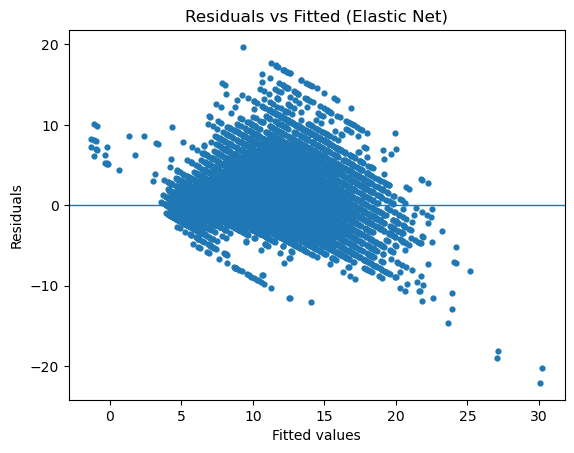

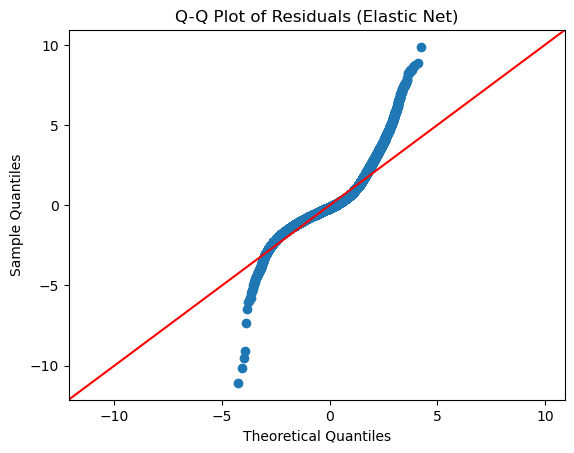

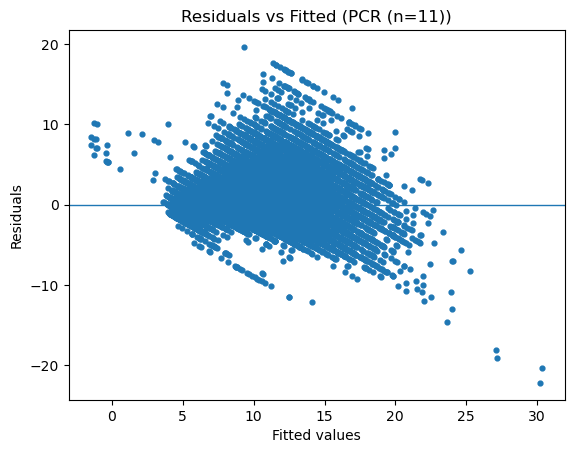

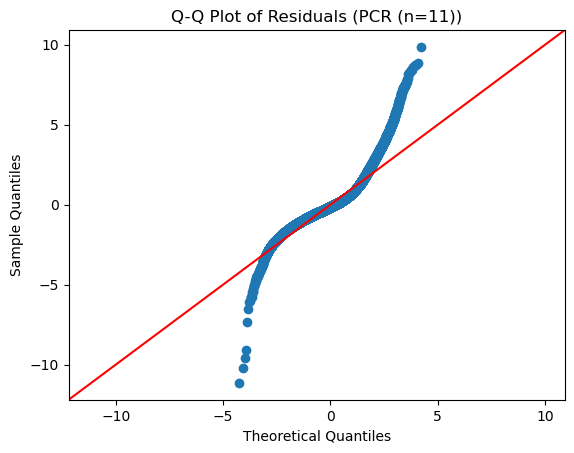

In [14]:
def diagnostics_from_pipeline(fitted_pipeline: Pipeline, X: pd.DataFrame, y: pd.Series, model_name: str):
    # Get fitted values on training set
    y_hat = fitted_pipeline.predict(X)
    resid = y - y_hat

    # Residuals vs fitted
    plt.figure()
    plt.scatter(y_hat, resid, s=12)
    plt.axhline(0, linewidth=1)
    plt.xlabel("Fitted values")
    plt.ylabel("Residuals")
    plt.title(f"Residuals vs Fitted ({model_name})")
    plt.show()

    # Q-Q plot
    sm.qqplot(resid, line="45", fit=True)
    plt.title(f"Q-Q Plot of Residuals ({model_name})")
    plt.show()

# Fit the two main models on full data for diagnostics
elastic_model.fit(X, y)

pcr_best = Pipeline(steps=[
    ("preprocess", preprocess),
    ("pca", PCA(n_components=best_n)),
    ("reg", LinearRegression())
])
pcr_best.fit(X, y)

diagnostics_from_pipeline(elastic_model, X, y, "Elastic Net")
diagnostics_from_pipeline(pcr_best, X, y, f"PCR (n={best_n})")


## Choose two models for Kaggle submissions

This section creates two submission files:

- `submission_regularized.csv` (Elastic Net)
- `submission_pcr.csv` (PCR)

The `id` column is used when present; otherwise the row index is used.


In [15]:
# Prepare test IDs
if ID_COL and ID_COL in test.columns:
    test_ids = test[ID_COL].copy()
else:
    test_ids = pd.Series(np.arange(len(test)), name="id")

# Fit final models on full training data
elastic_model.fit(X, y)
pcr_best.fit(X, y)

# Predict on test set
pred_enet = elastic_model.predict(test)
pred_pcr  = pcr_best.predict(test)

# Build submissions
sub_enet = pd.DataFrame({test_ids.name: test_ids, TARGET: pred_enet})
sub_pcr  = pd.DataFrame({test_ids.name: test_ids, TARGET: pred_pcr})

# Save in the same folder as the notebook (current working directory)
out_enet = Path.cwd() / "submission_regularized.csv"
out_pcr  = Path.cwd() / "submission_pcr.csv"

sub_enet.to_csv(out_enet, index=False)
sub_pcr.to_csv(out_pcr, index=False)

print("Wrote:", out_enet)
print("Wrote:", out_pcr)

sub_enet.head()


Wrote: c:\Users\toddd\Documents\Azure_DevOps\Career Development-1\Todd_DeLozier\School\National_University_PhD_Data_Science\Predictive_Analytics\Week_3\submission_regularized.csv
Wrote: c:\Users\toddd\Documents\Azure_DevOps\Career Development-1\Todd_DeLozier\School\National_University_PhD_Data_Science\Predictive_Analytics\Week_3\submission_pcr.csv


,id,Rings
0,90615,8.639578
1,90616,10.022378
2,90617,10.323006
3,90618,10.832025
4,90619,7.742978


## Model comparison summary (CV)

This table summarizes cross-validated RMSE for the baseline model, the regularized model, the subset-style model informed by regularization, and PCR.


In [16]:
# Recompute summary in one place
baseline_rmse, baseline_std = rmse_cv(Pipeline([("preprocess", preprocess), ("reg", LinearRegression())]), X, y)
enet_rmse, enet_std = rmse_cv(elastic_model, X, y)

# subset rmse already computed; keep it
pcr_rmse = float(pcr_df.iloc[0]["cv_rmse"])

summary = pd.DataFrame([
    ("Baseline OLS", baseline_rmse, baseline_std),
    ("Elastic Net (CV)", enet_rmse, enet_std),
    (f"Subset-style (top {best_k})", subset_rmse.mean(), subset_rmse.std()),
    (f"PCR (n={best_n})", pcr_rmse, np.nan),
], columns=["model", "cv_rmse_mean", "cv_rmse_std"])

display(summary.sort_values("cv_rmse_mean"))


,model,cv_rmse_mean,cv_rmse_std
2,Subset-style (top 10),1.995569,0.016887
0,Baseline OLS,1.995569,0.016887
3,PCR (n=11),1.995569,NaN
1,Elastic Net (CV),1.995966,0.016851
